# 8장 : 컨볼루션을 활용한 일반화

 + 컨볼루션 이해
 + 컨볼루션 신경망 만들기
 + 커스텀 `nn.Module` 서브클래스 만들기
 + 모듈과 함수형 API의 차이
 + 신경망 설계시 고려할 점

8장에서는 신경망에서 완전 연결된 어파인 변환 유닛을 또 다른 선형 연산인 컨볼루션으로 바꾸는 법에 대해 다룬다.

## 8.1 컨볼루션

이미지를 기준으로, 인접한 픽셀간의 정보를 사용하고 위치 변화에 대한 불변성을 획득하려면, 인근 픽셀의 배열 방식을 살펴봐야 한다(서로 멀리 떨어져 있는 픽셀들에 대해서는 관심이 없다).

이 개념을 수학적인 형태로 바꾸려면 이미지 내의 다른 픽셀이 아닌 바로 옆 픽셀에 대한 가중치의 합을 계산하면 된다. 출력 피처와 출력 픽셀 위치마다 가중치 행렬을 만드는 것인데, 센터가 되는 픽셀에서 일정 거리 이상 떨어진 경우 가중치가 0이 된다고 생각하면 된다. 이때 계산 결과는 여전히 가중치의 합이므로 선형 연산으로 볼 수 있다.

### 8.1.1 컨볼루션의 역할

$\textbf{컨볼루션}^{\text{convolution}}$ 은 이미지에 대해 지역적인, 평행이동 불변성을 보장하는 선형 연산이다.

조금 더 정확하게 $\textbf{이산 컨볼루션}^{\text{discrete convolution}}$ 은 2차원 이미지에 가중치 행렬을 스칼라곱으로 수행하는 것으로 정의한다. 가중치 행렬은 $\textbf{커널}^{\text{kernel}}$ 이라 부르며 입력의 모든 이웃에 대해 수행한다.

2차원 텐서인 $3 \times 3$ 크기의 커널을 사용한 컨볼루션의 예는 다음과 같다.

```python
weight = torch.tensor([[w00, w01, w02],
                       [w10, w11, w12],
                       [w20, w21, w22]])

image = torch.tensor([[i00, i01, i02, i03, ..., i0N],
                      [i10, i11, i12, i13, ..., i1N],
                      [i20, i21, i22, i23, ..., i2N],
                      ...
                      [iM0, iM1, iM2, iM3, ..., iMN]])

# 편향값이 없는 출력 이미지의 각 요소 계산
o11 = i11 * w00 + i12 * w01 + i13 * w02 +
      i21 * w10 + i22 * w11 + i23 * w12 +
      i31 * w20 + i32 * w21 + i33 * w22
```

이런 식으로 입력의 모든 위치에 대해 커널을 이동시켜 가면서 가중치의 합을 구해 출력 이미지를 만들 수 있다. RGB 이미지처럼 채널이 여러 개인 경우 가중치 행렬은 $3 \times 3 \times 3$ 행렬로 각 채널에 대한 가중치 집합이 존재하며, 이를 합쳐서 출력값 계산에 기여하게 된다.

커널의 가중치는 `nn.Linear`에서의 `weight`요소와 같이 미리 알 수 없으며, 랜덤으로 초기화되고 역전파를 통해 업데이트 된다. 동일한 커널의 각 가중치가 전체 이미지에 대해 계속 사용된다는 점도 기억하자. 자동미분을 생각하면 각 가중치가 전체 이미지를 훑은 결과라고 볼 수 있다. 이렇게 하기 때문에 컨볼루션 가중치에 대한 손실값의 미분은 이미지 전체가 기여한다고 볼 수 있다.

즉 컨볼루션은 어떤 한 픽셀 주위를 제외한 나머지의 가중치를 0으로 하는 여러 개의 선형 연산이며 훈련 중에 각각으로부터 동일한 업데이트를 받는다.

이렇게 컨볼루션을 사용하면

  - 주위 영역에 대한 지역 연산을 할 수 있고,
  - 평행이동 불변성을 가지며,
  - 더 적은 파라미터를 사용한다.

더 적은 파라미터만 쓰는 이유는 완전 연결 계층과는 달리 컨볼루션에서의 파라미터 수는 이미지 픽셀 수에 의존하지 않기 때문이다. 대신 컨볼루션 커널의 크기($3 \times 3, \quad 5 \times 5$ ... 식으로)와 모델서 얼마나 많은 컨볼루션 필터(혹은 출력 채널 수)를 쓰는지에 의존한다.

In [1]:
from torchvision import datasets, transforms
import sys, os
BASE_DIR = os.getcwd()
sys.path.append(BASE_DIR)
data_path = os.path.join(BASE_DIR, "data", "data-unversioned", "p1ch7")


cifar10 = datasets.CIFAR10(
    data_path, train=True, download=False,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465),
                             (0.2470, 0.2435, 0.2616))
    ]))

cifar10_val = datasets.CIFAR10(
    data_path, train=False, download=False,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465),
                             (0.2470, 0.2435, 0.2616))
    ]))



class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

label_map = {0: 0, 2: 1} # 0 : 비행기 -> 0으로 매핑, 2 : 새 -> 1로 매핑
class_names = ['airplane', 'bird']
cifar2 = [(img, label_map[label]) for img, label in cifar10 if label in [0, 2]] # 리스트 컴프리헨션을 통한 데이터 재구축 및 레이블 매핑
cifar2_val = [(img, label_map[label]) for img, label in cifar10_val if label in [0, 2]] # 되게 깔끔하다. (이 방법 말고도 다양한 방법 가능)

## 8.2 컨볼루션 사용해보기

`torch.nn`모듈은 1,2,3 차원에 대한 컨볼루션을 제공한다. `nn.Conv1d`는 시계열용이고 `nn.Conv2d`는 이미지용이며 `nn.Conv3d`는 용적 데이터나 동영상용이다.

CIFAR-10 데이터에 대해서는 `nn.Conv2d`를 사용한다. `nn.Conv2d`에 전달하는 인자는 최소 입력 피처 수(픽셀 하나당 둘 이상의 값을 가지는 멀티채널 이미지의 경우 채널 정보)와 출력 피처 수, 커널의 크기가 있어야 한다.

우리의 첫 컨볼루션 모듈은 RGB 채널을 가지니 픽셀당 3개의 입력 피처를 가지고 출력 피처는 임의로 16을 전달하자. 출력 이미지가 더 많은 채널을 가질 수록 신경망의 용량도 커진다. 현재는 각 채널이 다양한 종류의 피처를 발견하기 원한다. 또 이들을 랜덤으로 초기화하기 때문에 훈련 후에 어떤 피처는 필요없어질 수 있다(이는 복권가설 : lottery ticket hypothesis에 해당한다).

커널의 크기는 일반적으로 모든 방향으로 동일하게 만든다(예 : 2차원 컨볼루션은 $3 \times 3$, 3차원 컨볼루션은 $3 \times 3 \times 3$). 예외적으로 2부에서 살펴볼 CT 스캔 데이터는 세 개의 축중에 하나가 다른 $\text{복셀}^{\text{voxek}}$(3D 화소)을 갖는다. 이 경우에는 커널이 예외적인 차원에 대해 다른 크기를 가지는 것이 맞다. 지금은 모든 차원에 대해 동일한 크기를 가지는 컨볼루션에 집중하자.

In [2]:
import torch.nn as nn
import torch

conv = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3) # kernel_size는 3이나 (3,3)으로 전달해도 동일하다.
conv

Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1))

In [3]:
# 가중치 갯수 : in_channels x out_channels x kernel_size ** d -> 3 x 16 x 3 x 3
conv.weight.shape, conv.bias.shape

(torch.Size([16, 3, 3, 3]), torch.Size([16]))

In [4]:
# conv2d 예시
img, _ = cifar2[0]
img: torch.Tensor
output = conv(img.unsqueeze(0))
output: torch.Tensor
img.unsqueeze(0).shape, output.shape

(torch.Size([1, 3, 32, 32]), torch.Size([1, 16, 30, 30]))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8624594..2.0298588].


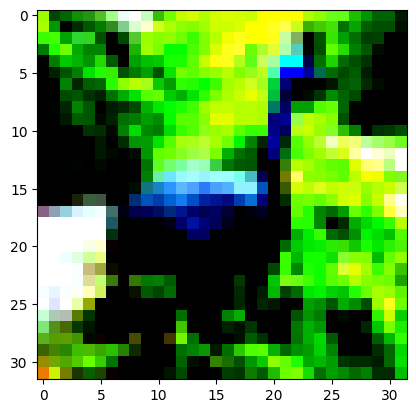

In [5]:
import matplotlib.pyplot as plt

plt.imshow(img.permute(1,2,0).detach())
plt.show()

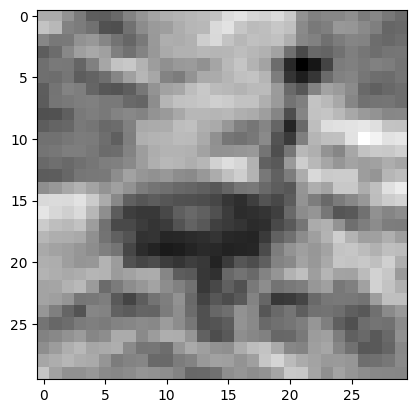

In [6]:
import matplotlib.pyplot as plt

plt.imshow(output[0, 0].detach(), cmap='gray')
plt.show()

### 8.2.1 경계 패딩하기

파이토치는 컨볼루션 커널을 입력 그림 안에서 미끌어지면서 이동하는데, 수평과 수직 위치는 `width - kernel_width + 1`로 구한다. 따라서 크기가 홀수인 컨볼루션 커널의 길이의 절반만큼(우리의 경우 3//2 = 1) 양쪽의 그림 이 잘린다. 이 때문에 각 차원에서 딱 두 픽셀만큼 없어진 것이다.

다행히 파이토치는 컨볼루션과 관련해 이미지의 경계에 값이 0인 $\textbf{가짜}^{\text{ghost}}$ 픽셀을 패딩해주는 기능을 제공한다.

우리의 경우 `kernel_size = 3`일 때 `padding = 1`로 지정하면 `i00`지점에서 왼쪽과 위쪽에 추가 이웃이 만들어진다. 그래서 원래 이미지에서 모서리에 해당하는 지점에서도 컨볼루션의 출력값을 계산할 수 있다. 덕분에 출력이 입력과 동일한 크기를 가진다(커널 크기가 짝수라면 왼쪽과 오른쪽을 다른 크기로 패딩해야 한다. 위쪽과 아래쪽도 마찬가지다. `torch.nn.nfunctional.pad`에서 이 기능을 제공하지만 왠만하면 커널 사이즈는 홀수로 지정하자).

컨볼루션에서 패딩을 사용하는 이유는 크게 두가지다. 

하나는 패딩을 통해서 컨볼루션과 이미지 크기 변경 문제를 별도로 분리해 기억해야 하는 사항을 하나 줄이는 데 도움을 준다.

다른 하나는 이를 통해 컨볼루션 구조 자체에 더 신경쓸 수 있다는 점이다. 8.5.3절에서 다룰 스킵 커넥션(skip connection)이나 2부에서 다룰 유넷(U-Net)같은 구조를 예로 들 수 있는데 몇 개의 컨볼루션 앞뒤의 텐서를 호환되는 크기로 만들면 쉽게 더하거나 뺄 수 있게 된다.

In [7]:
conv = nn.Conv2d(3, 1, kernel_size=3, padding= 1)
output = conv(img.unsqueeze(0))
img.unsqueeze(0).shape, output.shape

(torch.Size([1, 3, 32, 32]), torch.Size([1, 1, 32, 32]))

### 8.2.2 컨볼루션으로 피처 찾아내기

직접 가중치를 설정해서 컨볼루션에서 어떤 일이 일어나는지 알아보자.

먼저 `bias`를 0으로 제거해서 교란 변수를 배제하고, 가중치에 상수값을 넣어서 출력에서의 각 픽셀이 자신의 이웃 픽셀에 대한 평균을 가지게 해보자.

In [8]:
with torch.no_grad():
    conv.bias.zero_()
    
with torch.no_grad():
    conv.weight.fill_(1.0 / 9.0)

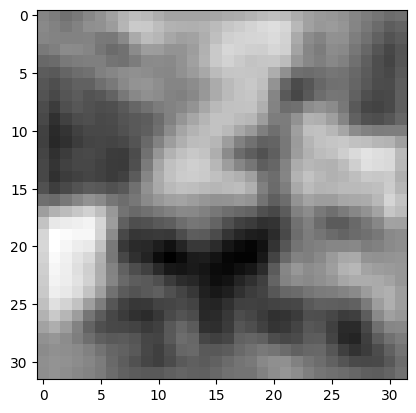

In [9]:
# 이미지가 흐려짐 : 각 출력 픽셀은 자신의 주변 픽셀에 대한 평균으로 출력 픽셀에서 이러한 상관관계를 반영해서 픽셀 간의 변화가 부드러워짐
output = conv(img.unsqueeze(0))
plt.imshow(output[0, 0].detach(), cmap = 'gray')
plt.show()

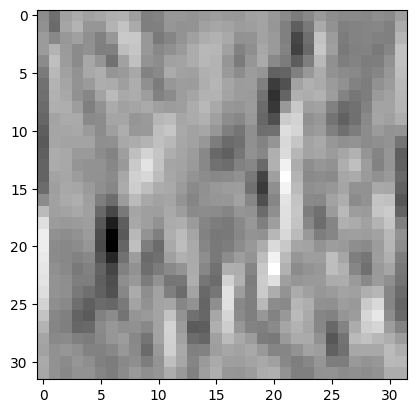

In [10]:
# 수직 경계를 강조하는 커널
conv = nn.Conv2d(in_channels=3, out_channels=1, kernel_size=3, padding=1)

with torch.no_grad():
    conv.weight[:] = torch.tensor([[-1.0, 0.0, 1.0],
                                   [-1.0, 0.0, 1.0],
                                   [-1.0, 0.0, 1.0]])
    conv.bias.zero_()
    
    

output = conv(img.unsqueeze(0))
output.shape
plt.imshow(output[0, 0].detach(), cmap = 'gray')
plt.show()

위에서 알 수 있듯이, 손실을 줄여가는 최적화를 통해 자동으로 컨볼루션 가중치가 업데이트 되는 과정에서, 모델은 이미지 픽셀간의 상관관계, 수직 경계, 수평이나 대각선 경계 혹은 십자 모양이나 체스판 패턴 등을 탐지하는 커널을 알아서 배우게 된다.

출력에 해당되는 채널은 피처에 자동으로 대응하게 되고, 각 채널은 이미지 픽셀의 다양한 종류의 경계를 강조한 맵이 된다.

### 8.2.3 깊이와 풀링으로 한 단계 더 인식하기

완전 연결 계층에서 컨볼루션으로 넘어오면서 지역성이나 평행이동 불변성을 해결했다. 그리고 $3 \times 3$ 혹은 $5 \times 5$ 같은 작은 커널을 사용하기를 추천했다. 이 정도 크기가 지역성의 한계다. 만약 이미지 내 그림이 꽤 크다면 어떻게 해야 할까? 이미지 안의 물체나 구조가 3픽셀이나 5픽셀밖에 안 될까? 우리는 알 수 없다. 모든 물체가 3~5 픽셀 정도로 작지는 않기 때문이다.

그렇다면 더 큰 범위에서 신경망이 패턴을 인식하게 하려면 어떻게 해야 할까? 가능한 방법 중 하나는 더 큰 컨볼루션 커널을 사용하는건데, $32 \times 32$ 크기 이미지에 대해 같은 크기의 커널인 $32 \times 32$ 크기의 커널을 사용하는 것이다. 하지만 이렇게 하면 이전에 다룬 완전 연결된 어파인 변환으로 수렴해서 컨볼루션의 장점을 잃어버리게 된다. 컨볼루션 신경망에서는 컨볼루션을 아례로 층층이 쌓으면서 동시에 연속적인 컨볼루션 사이의 이미지를 다운샘플링하는 또 다른 방법이 있다.

$\textbf{다운 샘플링}$ : 이미지를 반으로 줄이는 것은 이웃하는 네 개의 픽셀을 입력받아 한 픽셀을 출력하는 작업과 동일하다.
> 1. 네 개의 픽셀을 평균하기 : 초기에는 이와 같은 $\textbf{평균 풀링}^{\text{average pooling}}$ 이라는 방법이 일반적이었는데 요즘은 잘 사용하지 않는다.
> 2. 네 개의 픽셀 중 최댓값 : $\textbf{맥스 풀링}^{\text{max pooling}}$ 이라 불리는 이와 같은 접근 방법은 오늘날 가장 널리 사용되지만, 데이터의 4분의 3을 버린다는 단점이 있다.
> 3. 스트라이드하며 컨볼루션을 수행하되 n번째 픽셀만 계산하기 : $3 \times 4$ 컨볼루션을 스트라이드 2로 실행하면 이전 계층의 모든 픽셀을 포함한다. 이 방식의 가능성을 보여주는 논문이 있지만 아직 맥스 풀링을 대체할 정도는 아니다.

이중에서 맥스 풀링을 사용해보자.

직관적으로 생각해보면 다른 선형 계층처럼 활성 함수로 연결되므로 컨볼루션층의 출력 이미지의 각 값은(수직선처럼) 특정 커널에 대응하는 패턴이 발견될 때 높은 값을 가진다. 다운샘플링을 통해 $2 \times 2$ 인접 픽셀에서 최댓값을 뽑는 것은 약한 신호는 버리고 살아남은 피처를 발견하는 과정으로 볼 수 있다.

In [11]:
# max pooling : 입력으로 풀링 연산을 수행할 인접한 영역 크기를 받는다. 이미지를 절반으로 줄이고 싶다면 크기를 2로 지정한다.
pool = nn.MaxPool2d(kernel_size=2)
output = pool(img.unsqueeze(0))

img.unsqueeze(0).shape, output.shape 

(torch.Size([1, 3, 32, 32]), torch.Size([1, 3, 16, 16]))

$\textbf{더 나은 성능을 위해 컨볼루션과 다운 샘플링 결합하기}$

입력 이미지 -> 컨볼루션 -> 맥스 풀링 -> 컨볼루션 -> 맥스 풀링 -> ... -> 컨볼루션 -> 맥스 풀링 출력 -> 완전연결층 -> ...

위의 (컨볼루션 -> 맥스 풀링)이 반복되는 과정에서, 첫 번째 커널셋이 먼저 작은 영역 내에서 1차로 저수준의 피처에 대해 동작한다. 그리고 두 번째 커널셋은 이렇게 얻은 피처들을 합성한 피처를 만들고 좀 더 넓은 범위에 대해 효과적으로 작동한다. 이 과정이 반복되면서 결국 전체 이미지 범위에 대한 피처를 얻을 수 있게 된다. (32 크기의 이미지를 맥스풀링 kernel_size=2로 할 경우 이론적으로 한 4-5번정도 반복되면 충분한 피처를 학습 가능하다)

이런 메커니즘은 매우 강력한데 CIFAR-10 데이터셋에서 얻은 $32 \times 32$ 이미지보다 훨씬 더 복잡한 장면을 인식하는 컨볼루션 신경망을 제공한다.

### 8.2.4 우리의 신경망에 적용하기

이러한 빌딩 블럭들을 활용해서 새와 비행기를 탐지하는 컨볼루션 신경망을 만들 수 있다.

```python
model = nn.Sequential(
    nn.Conv2d(3, 16, kernel_size = 3, padding = 1),
    nn.Tanh(),
    nn.MaxPool2d(2),
    nn.Conv2d(16, 8, kernel_size = 3, padding = 1),
    nn.Tanh(),
    nn.MaxPool2d(2),
    # ...
)
```

첫 번째 컨볼루션은 3 RGB 채널을 16, 즉 16개의 독립적인 피처를 만들어 새와 비행기에 대한 저수준의 피처를 찾아낸다. 그리고 `Tanh` 활성 함수를 적용한다. 결과로 만들어진 16채널의 $32 \times 32$ 이미지는 이제 첫 `MaxPool2d`를 통해 16채널의 $16 \times 16$ 이미지로 다운 샘플링되고, 8채널의 $16 \times 16$ 출력을 만드는 다른 컨볼루션으로 들어간다. 이 출력은 이제 좀 더 높은 수준의 피처를 가질 것이다. 그리고 이어서 `Tanh` 활성 함수와 8채널 $8 \times 8$ 출력을 위한 풀링을 수행한다.

어디가 끝일까? 입력 이미지가 $8 \times 8$ 피처 세트로 줄어들고 난 후 이 신경망은 결국 음의 로그 가능도로 넣을 수 있는 확률값을 뽑아줘야 한다. 확률은 1차원 벡터인 숫자 쌍으로 나와야 하는데(하나는 비행기, 다른 하나는 새) 지금은 멀티 채널의 2차원 피처인 상태다.

이걸 하려면 8채널의 $8 \times 8$ 이미지를 1차원 벡터로 바꿔서 완전 연결 계층으로 신경망을 마무리해야 한다.

In [12]:
model = nn.Sequential(
    nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding = 1),
    nn.Tanh(),
    nn.MaxPool2d(2),
    nn.Conv2d(in_channels=16, out_channels=8, kernel_size=3, padding=1),
    nn.Tanh(),
    nn.MaxPool2d(2),
    nn.Flatten(),
    nn.Linear(8 * 8 * 8, 32),
    nn.Tanh(),
    nn.Linear(32, 2)
)

# 이 모델의 파라미터 수 : 입력 피처를 3072로 사용하던 완전연결 신경망의 파라미터수보다 확 줄어들었다.
numel_list = [p.numel() for p in model.parameters()]
sum(numel_list), numel_list

(18090, [432, 16, 1152, 8, 16384, 32, 64, 2])

In [13]:
model(img.unsqueeze(0))

tensor([[-0.1730,  0.0763]], grad_fn=<AddmmBackward0>)

위에서 마지막 `nn.MaxPool2d`의 출력에 대해 `view`를 호출하면 차원불일치 문제(`nn.Flatten` 사용하지 않는 경우)를 해결할 수 있지만 안타깝게도 `nn.Sequential` 을 사용할 때는 각 모듈의 출력을 명시적으로 볼 수 없다.

## 8.3 `nn.Module` 서브클래싱하기

신경망을 개발하다 보면 기존에 만들어진 모듈에서 지원하지 않는 연산이 필요할 때가 있다. 지금의 차원 정보 변경도 비슷하지만 8.5.3 절에서도 $\text{잔차}^{\text{residual}}$ 연결을 구현하기 위해서도 직접 만들 수 있어야 한다. 그래서 이 절에서는 `nn.Module`의 서브클래스를 직접 만드는 법을 배워서 이미 만들어져 있는 것이나 `nn.Sequential`처럼 사용할 수 있게 할 예정이다.

계층 뒤에 다른 계층을 붙이는 것보다 더 복잡한 일을 수행하는 모델을 만들려면 유연성을 위해 `nn.Sequential`을 버려야 한다. 파이토치에서는 `nn.Module` 서브클래싱으로 모델에서 어떤 연산이든 수행 가능하게 해준다.

`nn.Module`을 서브클래싱하려면 먼저 `forward` 함수를 정의하여 모듈로 입력을 전달하고 출력을 반환하게 해야 한다. 이 부분이 모듈의 연산을 정의하는 영역이다. `forward`를 보면 이 책의 앞부분이 생각날 것이다. 5.5.1 절에서 순방향과 역방향 경로를 정의해야 했던 모듈이 있었다. 파이토치에서는 표준 `torch` 연산을 사용하기만 한다면 자동미분 기능이 자동으로 역방향 경로를 만들어준다. 그래서 `nn.Module`에는 `backward`가 필요 없다.

우리가 만들 연산도 결국은 컨볼루션 같은 이미 있는 모듈이나 커스텀 모듈을 사용한다. 이 $\textbf{서브 모듈}^{\text{submodule}}$을 포함하려면 생성자 `__init__` 에 정의하고 `self`에 할당해서 `forward` 함수에서 사용할 수 있게 만들어야 한다. 이렇게 하면 모듈이 동작하는 동안 파라미터가 유지될 것이다. 모든 코드에 앞서 `super().__init__()`을 호출해야 함을 잊지 말자.

### 8.3.1 `nn.Module`로 정의된 우리의 신경망

In [14]:
class ConvNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.act1 = nn.Tanh()
        self.pool1 = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=8, kernel_size=3, padding=1)
        self.act2 = nn.Tanh()
        self.pool2 = nn.MaxPool2d(2)
        self.fc1 = nn.Linear(8 * 8 * 8, 32)
        self.act3 = nn.Tanh()
        self.fc2 = nn.Linear(32, 2)
        
    # 명시적으로 forward함수를 통해 self.pool2의 출력을 직접 조작해서 view를 통해 B x N 벡터로 만들 수 있다.
    # 배치에 얼마나 많은 샘플이 들어있을지 알 수 없기 때문에 view 호출시 배치 차원을 -1로 둔다.
    def forward(self, x):
        out = self.pool1(self.act1(self.conv1(x)))
        out = self.pool2(self.act2(self.conv2(out)))
        out = out.view(-1, 8 * 8 * 8)
        out = self.act3(self.fc1(out))
        out = self.fc2(out)
        return out

`nn.Module`의 서브클래스는 모델 전체를 담는 데 활용한다. 더 복잡한 신경망을 위한 새로운 빌딩 블럭을 정의하기 위해 이 서브클래스를 사용할 수도 있다.

### 8.3.2 파이토치가 파라미터와 서브모듈을 유지하는 방법

앞서의 코드에서는 생성자 안에서 `nn.Module`의 속성에 `nn.Module`의 인스턴스를 할당했었다.

이렇게 하면 재미있게도 모듈이 서브모듈로 등록된다(무슨 말이냐면, 언제든 호출 가능한 인스턴스로 사용가능하다는 뜻이다).

`nn.Module` 서브클래스의 메소드라면 언제나 호출 가능하다. 예를 들어 훈련 과정이 실제 사용(예측)때와 매우 다른 경우, 별도로 `predict` 메소드를 만드는게 나을 수도 있다. 이런 메소드의 호출은 모듈 자체보다는 `forward`메소드를 호출하는 것과 비슷해서, `hook`호출을 놓치게 되고 JIT는 사용시 모듈 구조를 볼 수 없다. `__call__`을 호출하지 않기 때문인데, 6.2.1절에서 다룬 것과 같은 맥락이다.

이렇게 하면 `ConvNet`은 사용자의 추가 행위 없이 서브모듈의 파라미터에 접근할 수 있게 된다.

In [15]:
model = ConvNet()

numel_list = [p.numel() for p in model.parameters()]
sum(numel_list), numel_list

(18090, [432, 16, 1152, 8, 16384, 32, 64, 2])

이제 모듈을 직접 만드는 법을 알았으며, 이런 기법은 2부에서 많이 필요할 것이다. `ConvNet`클래스 구현을 되돌아보고 생성자에서 서브모듈을 등록하는 과정을 생각해보면(`self.act1 = nn.Tanh`등) 파라미터가 없는 `nn.Tanh`나 `nn.MaxPool2d` 같은 서브 모듈은 굳이 등록할 필요가 없을 것 같다. 이들은 `view`호출처럼 그냥 `forward`함수에서 직접 호출하는 게 더 쉽지 않을까?

### 8.3.3 함수형 API

당연히 그렇다! 그런 이유로 파이토치는 모든 `nn`모듈에 대한 $\textbf{함수형}^{\text{functional}}$ 을 제공한다. 여기에서 '함수형'이란 내부 상태가 없다는 의미다. 즉 출력값이 전적으로 입력 인자에 의존한다. 실제로 `torch.nn.functional`은 `nn`에서 찾을 수 있는 모듈과 동일한 함수를 많이 제공한다. 다만 모듈에 저장된 파라미터와 입력 인자로 동작하는 것과는 달리 함수형이므로, 호출시 인자로 입력값 외에 파라미터도 받는다.

예를 들어 `nn.Linear`의 함수형은 `nn.functional.linear`인데, 함수 시그니처가 `linear(input, weight, bias=None)`이다. 함수 인자로 `weight`와 `bias`가 넘어간다. 풀링과 활성 함수의 경우 파라미터가 없으므로 안전하게 함수형으로 대체 가능하다.

In [16]:
import torch.nn.functional as F

class ConvNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=8, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(8 * 8 * 8, 32)
        self.fc2 = nn.Linear(32, 2)
        
    def forward(self, x):
        out = F.max_pool2d(torch.tanh(self.conv1(x)), 2)
        out = F.max_pool2d(torch.tanh(self.conv2(out)), 2)
        out = out.view(-1, 8 * 8 * 8)
        out = torch.tanh(self.fc1(out))
        out = self.fc2(out)
        return out

In [17]:
model = ConvNet()
model(img.unsqueeze(0))

tensor([[-0.0746, -0.1029]], grad_fn=<AddmmBackward0>)

## 8.4 우리가 만든 컨볼루션 신경망 훈련시키기

이제는 훈련 루프를 완벽하게 구성할 시점이다. 5장에서 이미지 전체 구조를 개발했고 훈련 루프는 6장에서 보던 것과 매우 흡사하다. 하지만 정확도 추적을 위해 조금만 수정해보자. 모델을 실행한 다음에는 이왕이면 빠르게 학습하기 위해 GPU에서 고속으로 돌리는 법을 다뤄보자.

먼저 우리가 만든 컨볼루션 신경망은 중첩된 두 루프를 가지고 있음을 주목하자. 바깥 루프는 에포크 단위로 돌고, 안쪽 루프는 `Dataset`에서 배치를 만드는 `DataLoader` 단위로 돈다. 각 루프에서는

  1. 모델에 입력값을 넣고(순방향 전달)
  2. 손실값을 계산하고(마찬가지로 순방향 전달)
  3. 이전 기울기값을 0으로 리셋하고
  4. `loss.backward()`를 호출하여 모든 파라미터에 대한 손실값의 기울기를 계산한다(역방향 전달).
  5. 이후 옵티마이저를 통해 손실값을 낮추도록 파라미터를 조정한다.

동시에 몇가지 정보를 수집해서 출력도 한다.

In [18]:
import time

def training_loop(n_epochs, optimizer:torch.optim.SGD, model, loss_fn, train_loader):
    for epoch in range(1, n_epochs + 1):
        t0 = time.time()
        loss_train = 0.0
        for imgs, labels in train_loader:
            # imgs: torch.Tensor
            # labels: torch.Tensor
            # imgs = imgs.to(device = "cuda")
            # labels = labels.to(device = "cuda")
            outputs = model(imgs)
            loss = loss_fn(outputs, labels)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            loss_train += loss.item()
            
        if epoch <= 10 or epoch % 10 == 0:
            print(f"Epoch {epoch}, Training loss : {loss_train / len(train_loader):.4f}, elapsed {time.time() - t0 :.4f}s")

In [19]:
train_loader = torch.utils.data.DataLoader(cifar2, batch_size = 64, shuffle=True)

model = ConvNet()
# model = model.to(device="cuda")
optimizer = torch.optim.SGD(model.parameters(), lr = 1e-2)
loss_fn = nn.CrossEntropyLoss()

training_loop(
    n_epochs=100,
    optimizer=optimizer,
    model=model,
    loss_fn=loss_fn,
    train_loader=train_loader
)

Epoch 1, Training loss : 0.5791, elapsed 13.1677s
Epoch 2, Training loss : 0.4907, elapsed 11.1471s
Epoch 3, Training loss : 0.4594, elapsed 10.4182s
Epoch 4, Training loss : 0.4345, elapsed 11.4635s
Epoch 5, Training loss : 0.4109, elapsed 11.1460s
Epoch 6, Training loss : 0.3901, elapsed 10.8871s
Epoch 7, Training loss : 0.3700, elapsed 11.4779s
Epoch 8, Training loss : 0.3563, elapsed 11.6076s
Epoch 9, Training loss : 0.3437, elapsed 10.8645s
Epoch 10, Training loss : 0.3339, elapsed 11.3193s
Epoch 20, Training loss : 0.2941, elapsed 11.0660s
Epoch 30, Training loss : 0.2703, elapsed 11.1608s
Epoch 40, Training loss : 0.2507, elapsed 11.3390s
Epoch 50, Training loss : 0.2289, elapsed 11.1236s
Epoch 60, Training loss : 0.2115, elapsed 9.8983s
Epoch 70, Training loss : 0.1950, elapsed 11.2928s
Epoch 80, Training loss : 0.1810, elapsed 5.2006s
Epoch 90, Training loss : 0.1633, elapsed 5.6700s
Epoch 100, Training loss : 0.1492, elapsed 5.5983s


### 8.4.1 정확도 측정

손실값보다 해석하기 좋은 측정 방법으로 훈련셋과 검증셋을 통한 정확도 측정을 생각해볼 수 있다.

In [20]:
train_loader = torch.utils.data.DataLoader(cifar2, batch_size = 64, shuffle=False)
val_loader = torch.utils.data.DataLoader(cifar2_val, batch_size = 64, shuffle=False)

def validate(model, train_loader, val_loader):
    for name, loader in [("train", train_loader), ("val", val_loader)]:
        correct = 0
        total = 0
        
        with torch.no_grad():
            for imgs, labels in loader:
                outputs = model(imgs)
                _, predicted = torch.max(outputs, dim = 1)
                total += labels.shape[0]
                correct += int((predicted == labels).sum())
                
        print(f"Accuracy {name} : {correct / total :.4f}")
        
validate(model, train_loader, val_loader)

Accuracy train : 0.9371
Accuracy val : 0.8970


### 8.4.2 모델을 저장하고 불러오기

이 정도면 만족할 만한 모델이므로, 이제 저장해보면 되지 않을까? 저장은 쉽다. 파일로 모델을 저장해보자.

In [21]:
torch.save(model.state_dict(), data_path + 'birds_vs_airplanes.pt')

In [22]:
# 모델 불러오기
loaded_model = ConvNet()
loaded_model.load_state_dict(torch.load(data_path + 'birds_vs_airplanes.pt'))

<All keys matched successfully>

### 8.4.3 GPU에서 훈련시키기

`.to`메소드를 통해 데이터 로더에서 얻은 텐서를 GPU로 옮길 수 있다. 이러한 연산 작업은 자연스럽게 GPU위에서 이루어진다.

당연히 파라미터도 GPU로 옮길 필요가 있다. 다행히 `nn.Module`도 `.to`메소드가 있어서 모든 파라미터를 GPU로 옮길 수 있다.

`Module.to`와 `Tensor.to`는 조금 다르다는 점에 유의할 필요가 있다. `Module.to`는 모듈 인스턴스 자체를 수정한다(즉 `model.to(device = "cuda")`와 같이 써도 된다). 하지만 `Tensor.to`는 (연산중에서는 `Tensor.tanh`와 유사하게) 새 텐서를 반환한다(즉 `img_tensor = img_tensor.to(device = "cuda")`와 같이 써야 한다). 파라미터를 원하는 디바이스로 이동 후 `Optimizer`를 만드는 식의 구현을 추천한다.

가능하다면 GPU로 옮겨 작업하는 방식도 추천한다. `torch.cuda.is_available`값에 따라 `device`변수를 설정하는 것이 좋은 구현 패턴이다.

In [23]:
device = (torch.device('cuda') if torch.cuda.is_available() == True
          else torch.device('cpu'))

print(f"Training on device {device}.")

Training on device cuda.


In [24]:
def validate_cuda(model, train_loader, val_loader, device):
    if device != torch.device('cuda'):
        print("Please select device as cuda.")
        return None
    for name, loader in [("train", train_loader), ("val", val_loader)]:
        correct = 0
        total = 0
        
        with torch.no_grad():
            for imgs, labels in loader:
                imgs: torch.Tensor
                labels: torch.Tensor
                imgs = imgs.to(device = device)
                labels = labels.to(device = device)
                outputs = model(imgs)
                _, predicted = torch.max(outputs, dim = 1)
                total += labels.shape[0]
                correct += int((predicted == labels).sum())
                
        print(f"Accuracy {name} : {correct / total :.4f}")

In [25]:
import time

def training_loop_cuda(n_epochs, optimizer:torch.optim.SGD, model, loss_fn, train_loader, device):
    for epoch in range(1, n_epochs + 1):
        t0 = time.time()
        loss_train = 0.0
        for imgs, labels in train_loader:
            imgs: torch.Tensor
            labels: torch.Tensor
            imgs = imgs.to(device = device)
            labels = labels.to(device = device)
            outputs = model(imgs)
            loss = loss_fn(outputs, labels)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            loss_train += loss.item()
            
        if epoch <= 10 or epoch % 10 == 0:
            print(f"Epoch {epoch}, Training loss : {loss_train / len(train_loader):.4f}, elapsed {time.time() - t0 :.4f}s")
            
            
train_loader = torch.utils.data.DataLoader(cifar2, batch_size = 64, shuffle=True)

model_cuda = ConvNet().to(device=device)
optimizer = torch.optim.SGD(model_cuda.parameters(), lr = 1e-2)
loss_fn = nn.CrossEntropyLoss()

training_loop_cuda(
    n_epochs=100,
    optimizer=optimizer,
    model=model_cuda,
    loss_fn=loss_fn,
    train_loader=train_loader,
    device = device
)

Epoch 1, Training loss : 0.6046, elapsed 0.6614s
Epoch 2, Training loss : 0.4956, elapsed 0.3713s
Epoch 3, Training loss : 0.4623, elapsed 0.3503s
Epoch 4, Training loss : 0.4299, elapsed 0.3861s
Epoch 5, Training loss : 0.3969, elapsed 0.3612s
Epoch 6, Training loss : 0.3726, elapsed 0.3774s
Epoch 7, Training loss : 0.3532, elapsed 0.3768s
Epoch 8, Training loss : 0.3427, elapsed 0.3856s
Epoch 9, Training loss : 0.3321, elapsed 0.3703s
Epoch 10, Training loss : 0.3285, elapsed 0.3817s
Epoch 20, Training loss : 0.2964, elapsed 0.3795s
Epoch 30, Training loss : 0.2748, elapsed 0.4171s
Epoch 40, Training loss : 0.2542, elapsed 0.3710s
Epoch 50, Training loss : 0.2307, elapsed 0.3399s
Epoch 60, Training loss : 0.2146, elapsed 0.3630s
Epoch 70, Training loss : 0.1973, elapsed 0.3993s
Epoch 80, Training loss : 0.1837, elapsed 0.3587s
Epoch 90, Training loss : 0.1708, elapsed 0.3714s
Epoch 100, Training loss : 0.1551, elapsed 0.4016s


In [26]:
train_loader = torch.utils.data.DataLoader(cifar2, batch_size = 64, shuffle=False)
val_loader = torch.utils.data.DataLoader(cifar2_val, batch_size = 64, shuffle=False)

validate_cuda(model = model_cuda, train_loader=train_loader, val_loader=val_loader, device=device)

Accuracy train : 0.9417
Accuracy val : 0.8980


In [27]:
# Bigger model
import torch.nn.functional as F

class ConvNetLarge(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.conv1_dropout = nn.Dropout2d(p = 0.2)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=16, kernel_size=3, padding=1)
        self.conv2_dropout = nn.Dropout2d(p = 0.2)
        self.conv3 = nn.Conv2d(in_channels=16, out_channels=8, kernel_size=3, padding=1)
        self.conv3_dropout = nn.Dropout2d(p = 0.2)
        self.conv4 = nn.Conv2d(in_channels=8, out_channels=8, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(8 * 2 * 2, 128)
        self.fc1_dropout = nn.Dropout(p = 0.4)
        self.fc2 = nn.Linear(128, 64)
        self.fc2_dropout = nn.Dropout(p = 0.4)
        self.fc3 = nn.Linear(64, 32)
        self.fc3_dropout = nn.Dropout(p = 0.4)
        self.fc4 = nn.Linear(32, 2)
        
    def forward(self, x:torch.Tensor):
        out = F.max_pool2d(torch.relu(self.conv1(x)), 2)
        out = self.conv1_dropout(out)
        out = F.max_pool2d(torch.relu(self.conv2(out)), 2)
        out = self.conv2_dropout(out)
        out = F.max_pool2d(torch.relu(self.conv3(out)), 2)
        out = self.conv3_dropout(out)
        out = F.max_pool2d(torch.relu(self.conv4(out)), 2)
        out = out.view(-1, 8 * 2 * 2)
        out = torch.relu(self.fc1(out))
        out = self.fc1_dropout(out)
        out = torch.relu(self.fc2(out))
        out = self.fc2_dropout(out)
        out = torch.relu(self.fc3(out))
        out = self.fc3_dropout(out)
        out = self.fc4(out)
        return out


In [28]:
model_large = ConvNetLarge()

numel_list = [p.numel() for p in model_large.parameters()]
print(sum(numel_list), numel_list)

21890 [864, 32, 4608, 16, 1152, 8, 576, 8, 4096, 128, 8192, 64, 2048, 32, 64, 2]


In [29]:
test_tensor = torch.randn(64 * 3 * 32 * 32).reshape(64, 3, 32, 32).to(device="cuda")

model_large.to(device = "cuda")

model_large(test_tensor)

tensor([[-0.1290,  0.2233],
        [-0.1510,  0.2178],
        [-0.1076,  0.2484],
        [-0.1109,  0.1790],
        [-0.0799,  0.2216],
        [-0.0829,  0.1974],
        [-0.1624,  0.2331],
        [-0.0959,  0.1489],
        [-0.1075,  0.3112],
        [-0.1119,  0.1763],
        [-0.1269,  0.2632],
        [-0.1272,  0.1776],
        [-0.1129,  0.2107],
        [-0.1331,  0.2541],
        [-0.1843,  0.2010],
        [-0.1269,  0.2457],
        [-0.1484,  0.2224],
        [-0.1558,  0.2566],
        [-0.1088,  0.2102],
        [-0.0983,  0.2565],
        [-0.1416,  0.2362],
        [-0.1062,  0.2513],
        [-0.1524,  0.2580],
        [-0.1075,  0.1886],
        [-0.0948,  0.2742],
        [-0.0659,  0.1766],
        [-0.1662,  0.2386],
        [-0.0992,  0.2542],
        [-0.1406,  0.2195],
        [-0.0769,  0.1665],
        [-0.0799,  0.2296],
        [-0.0917,  0.1834],
        [-0.0762,  0.1826],
        [-0.1203,  0.2636],
        [-0.1371,  0.2001],
        [-0.0733,  0

In [30]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f"device : {device}")

train_loader = torch.utils.data.DataLoader(cifar2, batch_size = 64, shuffle=True, 
                                           num_workers=4, pin_memory=True, persistent_workers=True)

model_large = ConvNetLarge()
model_large = model_large.to(device=device)
optimizer = torch.optim.AdamW(model_large.parameters(), lr = 0.001)
loss_fn = nn.CrossEntropyLoss()


def training_loop_large(n_epochs, optimizer:torch.optim.AdamW, model:ConvNetLarge, loss_fn, train_loader, device):
    for epoch in range(1, n_epochs + 1):
        t0 = time.time()
        loss_train = 0.0
        for imgs, labels in train_loader:
            imgs: torch.Tensor
            labels: torch.Tensor
            imgs = imgs.to(device = device, non_blocking=True)
            labels = labels.to(device = device, non_blocking=True)
            outputs = model(imgs)
            loss = loss_fn(outputs, labels)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            loss_train += loss.item()
            
        if epoch <= 10 or epoch % 10 == 0:
            print(f"Epoch {epoch}, Training loss : {loss_train / len(train_loader):.4f}, elapsed {time.time() - t0 :.4f}s")

training_loop_large(
    n_epochs=400,
    optimizer=optimizer,
    model=model_large,
    loss_fn=loss_fn,
    train_loader=train_loader,
    device = device
)

device : cuda
Epoch 1, Training loss : 0.5861, elapsed 10.8992s
Epoch 2, Training loss : 0.4570, elapsed 0.7426s
Epoch 3, Training loss : 0.4150, elapsed 0.7041s
Epoch 4, Training loss : 0.4005, elapsed 0.7168s
Epoch 5, Training loss : 0.3785, elapsed 0.7380s
Epoch 6, Training loss : 0.3613, elapsed 0.7556s
Epoch 7, Training loss : 0.3554, elapsed 0.7629s
Epoch 8, Training loss : 0.3368, elapsed 0.7788s
Epoch 9, Training loss : 0.3349, elapsed 0.7697s
Epoch 10, Training loss : 0.3331, elapsed 0.7598s
Epoch 20, Training loss : 0.2861, elapsed 0.8022s
Epoch 30, Training loss : 0.2653, elapsed 0.8330s
Epoch 40, Training loss : 0.2454, elapsed 0.7909s
Epoch 50, Training loss : 0.2378, elapsed 0.7522s
Epoch 60, Training loss : 0.2212, elapsed 0.8294s
Epoch 70, Training loss : 0.2128, elapsed 0.7702s
Epoch 80, Training loss : 0.2142, elapsed 0.7655s
Epoch 90, Training loss : 0.2027, elapsed 0.7513s
Epoch 100, Training loss : 0.2001, elapsed 0.7439s
Epoch 110, Training loss : 0.1980, elapsed 

In [31]:
train_loader = torch.utils.data.DataLoader(cifar2, batch_size = 64, shuffle=False)
val_loader = torch.utils.data.DataLoader(cifar2_val, batch_size = 64, shuffle=False)

model_large.eval()
validate_cuda(model = model_large, train_loader=train_loader, val_loader=val_loader, device=device)

Accuracy train : 0.9760
Accuracy val : 0.9020


신경망의 가중치를 읽어올 때 문제가 하나 있다. 파이토치는 가중치를 저장할 때 어떤 디바이스를 기억해뒀다가 반대로 읽어들일 때도 해당 디바이스를 사용하므로, GPU에 있던 가중치는 나중에 GPU로 복구될 것이다. 나중에 어떤 디바이스에서 돌릴지 모르니, 신경망을 CPU로 옮긴 후에 저장하든가 아니면 파일에서 읽어들인 후 CPU로 옮기든가 해야 한다. 이를 간단하게 하려면 가중치를 로딩할 때 파이토치가 기억하는 디바이스 정보를 덮어쓰면 된다. `torch.load`인자에 `map_location` 키워드를 전달한다.

In [32]:
loaded_model = ConvNet().to(device=device)
loaded_model.load_state_dict(torch.load(data_path + 'birds_vs_airplanes.pt', map_location=device))

<All keys matched successfully>

## 8.5 모델 설계

지금까지 `nn.Module` 서브클래스를 사용해서 모델을 만들었고, 모델 훈련에 GPU를 어떻게 사용하는지도 다뤘다.

그런데 새와 비행기를 분류하는 데이터셋말고, 좀 더 복잡한 데이터셋은 어떻게 대응해야 할까? 만약 $\text{이미지넷}^{\text{ImageNet}}$처럼 더 크고 복잡한 이미지에서 답을 찾으려면, 여러 시각적 단서를 찾기 위해 계층적인 구조화가 필요하다. 예를 들어 작은 벽돌 모양이 리모컨인지 핸드폰인지 예측을 시도할 경우, 신경망은 스크린같이 생긴 사물을 찾으려 할 것이다.

게다가 실세계의 많은 문제가 다 이미지에 대한 것은 아니다. 테이블 데이터나 시계열, 텍스트까지 다룰 수도 있다. 신경망은 적절한 아키텍처(즉 계층이나 모듈의 연결 구조)와 적절한 손실 함수가 주어질 경우, 이런 종류의 데이터를 대상으로 문제를 풀만큼 충분히 유연하다는 특징이 있다.

파이토치는 매우 다양한 모듈과 손실 함수를 담은 채로 제공되기 때문에 단순한 피드포워드 요소부터 $\text{장단기 메모리}^{\text{LSTM, long short-term memory}}$ 모듈과 트랜스포머 신경망(이 두 아키텍처는 시계열 데이터를 위한 아키텍처로 유명하다)까지 구현할 수 있다. 몇몇 모델은 파이토치 허브에서 받을 수 있고 `torchvision`일부로 들어 있기도 하며 그 외 분야별 커뮤니티에서도 구할 수 있다.

2부에서는 고급 아키텍처를 살펴볼 예정이다. CT 스캔을 처음부터 끝까지 살펴보되 일반적인 경우로 한정해서 다룰 것이다. 신경망 아키텍처에 대한 여러 변형은 이 책의 범위를 벗어난다. 이번 절의 목적은 개념적인 도구를 다뤄보면서 최신 논문을 읽고 바로 파이토치로 구현하거나 때때로 저자들이 논문과 함께 제공하는 파이토치 구현을 막힘없이 술술 읽어내려가게 하는 것이다(중요).

### 8.5.1 메모리 용량 늘리기: 너비

신경망의 $\text{너비}^{\text{width}}$ 차원 늘리기 : 신경망 계층 내의 뉴런 수 혹은 컨볼루션의 채널 수에 해당하는 값

In [33]:
# 첫번째 컨볼루션 계층의 출력 채널 16 -> 32
class Netwidth(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 16, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(16 * 8 * 8, 32)
        self.fc2 = nn.Linear(32, 2)
        
    def forward(self, x):
        out = F.max_pool2d(torch.tanh(self.conv1(x)), 2)
        out = F.max_pool2d(torch.tanh(self.conv2(out)), 2)
        out = out.view(-1, 16 * 8 * 8)
        out = torch.tanh(self.fc1(out))
        out = self.fc2(out)
        return out       

In [34]:
# 모델 정의에서 하드코딩 피하기
class Netwidth(nn.Module):
    def __init__(self, n_chans_1 = 32):
        super().__init__()
        self.n_chans_1 = n_chans_1
        self.conv1 = nn.Conv2d(3, n_chans_1, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(n_chans_1, n_chans_1 // 2, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(8 * 8 * n_chans_1 // 2, 32)
        self.fc2 = nn.Linear(32, 2)
        
    def forward(self, x):
        out = F.max_pool2d(torch.tanh(self.conv1(x)), 2)
        out = F.max_pool2d(torch.tanh(self.conv2(out)), 2)
        out = out.view(-1, (self.n_chans_1 // 2) * 8 * 8)
        out = torch.tanh(self.fc1(out))
        out = self.fc2(out)
        return out       

### 8.5.2 모델이 수렴하고 일반화하도록 돕는 방법 : 정규화

모델 훈련은 중요한 두 단계를 거친다. 하나는 최적화 단계로서, 훈련셋에 대해 손실값을 줄이는 경우이고, 다른 하나는 일반화 단계로서, 모델이 훈련셋뿐 아니라 이전에 겪어보지 않은 검증셋 같은 데이터에 대해서도 동작하게 하는 것이다. 이 두 단계를 위한 수학적 도구를 모아서 $\textbf{정규화}^{\text{regularization}}$라는 이름을 붙이기도 한다.

> 1. $\textbf{파라미터 제어하기 : 가중치 페널티}$

$\text{일반화}^{\text{generalization}}$ 를 안정적으로 수행하기 위한 첫 번째 방법으로 손실값에 정규화 항을 넣는 것이 있다. 이 정규화 항을 조작해서 모델의 가중치가 상대적으로 작게 만든다. 즉 훈련을 통해 증가할 수 있는 크기를 제한하는 것이다. 큰 가중치 값에 페널티를 부과하는 셈이다. 이러면 손실값은 다소 매끄러운 등고선 형태를 띠는데 개별 샘플에 맞춰서 얻는 이득이 상대적으로 줄어들게 된다.

L2 정규화는 $\text{가중치 감쇠}^{\text{weight decay}}$라고도 한다. 이런 이름을 가진 이유는 SGD와 역전파를 생각해보면 되는데, 파라미터 `w_i`에 대한 L2 정규화의 음의 기울기는 `-2 * lambda * w_i`로, 여기에서 `lambda`는 하이퍼파라미터에 해당하며 파이토치에서는 간단히 가중치 감쇠라고 부른다. 

그래서 손실 함수에 L2 정규화를 더하는 것은 최적화 단계에서 현재 값에 비례해서 각 가중치를 줄이는 역할을 한다(가중치 감쇠라고 부르는 이유). 가중치 감쇠는 편향값 같은 신경망의 모든 파라미터에 적용된다.

파이토치에서 정규화는 손실값에 항을 하나 추가하는 것으로 매우 손쉽게 구현할 수 있다. 손실값 계산 후 손실 함수가 어떤 것이든지 간에 모델의 각 파라미터를 돌면서 (L2를 위한) 제곱이나 (L1을 위한) 절댓값을 더하고 역전파할 수 있다.

In [35]:
def training_loop_reg(n_epochs, optimizer:torch.optim.AdamW, model:ConvNetLarge, loss_fn, train_loader, reg, device):
    for epoch in range(1, n_epochs + 1):
        t0 = time.time()
        loss_train = 0.0
        for imgs, labels in train_loader:
            imgs: torch.Tensor
            labels: torch.Tensor
            imgs = imgs.to(device = device)
            labels = labels.to(device = device)
            outputs = model(imgs)
            loss = loss_fn(outputs, labels)
            
            l_lambda = 0.001
            if reg == "l2":
                l_norm = sum(p.pow(2.0).sum() for p in model.parameters())
            elif reg == "l1":
                l_norm = sum(p.abs().sum() for p in model.parameters())
            loss = loss + l_lambda * l_norm
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            loss_train += loss.item()
            
        if epoch <= 10 or epoch % 10 == 0:
            print(f"Epoch {epoch}, Training loss : {loss_train / len(train_loader):.4f}, elapsed {time.time() - t0 :.4f}s")

그런데 파이토치의 SGD 옵티마이저에는 이미 `weight_decay` 파라미터가 있고 `2 * lambda` 값을 가지며 업데이트 동작시 앞에서 설명한 것처럼 가중치 감쇠를 수행한다. 손실값에 가중치의 L2 정규화를 더한 것과 동일하므로, 자동미분과 손실값에서 항을 누적하는 작업을 할 필요가 없다.

> 2. $\textbf{입력 하나에 너무 의존하지 않기 : 드랍아웃}$

$\text{드랍아웃}^{\text{dropout}}$ 에 대한 개념은매우 단순하다. 훈련을 반복할 때마다 신경망의 뉴런 출력을 랜덤하게 0으로 만드는 작업을 일어나게 하는 것이다.

이 방법을 활용하면, 매 훈련 때마다 조금씩 다른 뉴런의 토폴로지가 만들어지기 때뭉네 신경망이 각 입력 샘플을 암기하려는 기회를 줄이므로 과적합을 방지한다. 다른 관점에서 드랍아웃은 모델이 피처를 만들려는 것을 교란해서 데이터 증강과 비슷한 효과를 내지만, 증강과 다르게 신경망 전체에 이러한 효과를 낸다(이론적으로 선형 신경망은 드랍아웃이 가지는 효과가 L2 정규화와 동일하며, 비선형 활성함수를 사용하는 경우 근사적으로 L2 정규화와 같은 효과를 갖는다 : Understanding Dropout)

파이토치에서는 비선형 활성 함수와 선형 혹은 여러 계층의 컨볼루션 모듈 사이에 `nn.Dropout`모듈을 넣어 모델의 드랍아웃을 구현할 수 있다. 인자로는, 어떤 입력이 0이 될지에 대한 확률을 지정해준다. 컨볼루션은 전용 값이 `nn.Dropout2d`나 `nn.Dropout3d`를 사용해서 해당 입력값의 채널 전부를 0으로 만든다.

In [36]:
class NetDropout(nn.Module):
    def __init__(self, n_chans_1 = 32):
        super().__init__()
        self.n_chans_1 = n_chans_1
        self.conv1 = nn.Conv2d(3, n_chans_1, kernel_size = 3, padding=1)
        self.conv1_dropout = nn.Dropout2d(p=0.4)
        self.conv2 = nn.Conv2d(n_chans_1, n_chans_1 // 2, kernel_size = 3, padding=1)
        self.conv2_dropout = nn.Dropout2d(p=0.4)
        self.fc1 = nn.Linear(8 * 8 * n_chans_1 // 2, 32)
        self.fc2 = nn.Linear(32, 2)
        
    def forward(self, x):
        out = F.max_pool2d(torch.tanh(self.conv1(x)), 2)
        out = self.conv1_dropout(out)
        out = F.max_pool2d(torch.tanh(self.conv1(out)), 2)
        out = self.conv2_dropout(out)
        out = out.view(-1, 8 * 8 * self.n_chans_1 // 2)
        out = torch.tanh(self.fc1(out))
        out = self.fc2(out)
        return out

드랍아웃은 훈련이 아닌 추론시에는 비활성화해야 한다(그렇지 않으면 매 추론시에 랜덤한 결과를 얻고, 또한 신경망의 전체 뉴런을 사용하지 않으므로 성능 또한 낮다. 그런데 이러한 특성을 고려하여 신경망의 불확실성을 측정하는 연구도 있다 : Monte Carlo Dropout). 

파이토치는 `nn.Model` 서브클래스에 대해 `model.train()` 혹은 `model.eval()` 호출로 전환 가능함을 기억하자. 이 호출은 서브 모듈에도 자동으로 적용되므로 그중에 `Dropout`이 있다면 순방향 또는 역방향 전달시 원하는대로 모드가 전환되어 동작할 것이다.

> 3. $\textbf{활성함수 억제하기 : 배치 정규화}$

$\text{배치 정규화}^{\text{batch normalization}}$ 는 드랍아웃이 대유행하던 2015년에 구글에서 발표된 방법이다. 학습률을 높이면서, 훈련은 초기화에 영향을 덜 받고 정규화처럼 동작해서, 결과적으로 드랍아웃에 대한 대체 방법이 된다.

배치 정규화의 핵심은 입력 범위를 신경망의 활성 함수로 바꿔서 미니 배치가 원하는 분포를 가지게 하는 것이다. 실제로 배치 정규화는 미니 배치 샘플을 통해 중간 위치에서 얻은 평균과 표준편차를 사용하여 중간 입력값을 이동하고 범위를 바꾼다. 따라서 모델이 보는 개별 샘플이나 이로 인한 이후의 활성화 단계에서는 랜덤하게 뽑아 만들어진 미니 배치에서 통계에 의존한 값의 이동과 범위 조정이 반영되어 있는 상태다. 이 자체로 원칙적인 데이터 증강인 셈이다. 배치 정규화 원논문에서 저자진은 배치 정규화가 드랍아웃할 필요를 없애거나 줄여준다고 주장한다.

파이토치의 배치 정규화는 `nn.BatchNorm1d`, `nn.BatchNorm2d`, `nn.BatchNorm3d` 모듈로 지원하며 각 입력 차원에 따라 골라 사용한다. 배치 정규화의 목적은 활성 함수의 입력 범위를 조정하는 것이므로 자연스럽게 선형 변환(우리의 경우에는 컨볼루션) 뒤에 위치하게 된다.

In [37]:
class NetBatchNorm(nn.Module):
    def __init__(self, n_chans_1 = 32):
        super().__init__()
        self.n_chans_1 = n_chans_1
        self.conv1 = nn.Conv2d(3, n_chans_1, kernel_size = 3, padding=1)
        self.conv1_batch_norm = nn.BatchNorm2d(num_features=n_chans_1)
        self.conv2 = nn.Conv2d(n_chans_1, n_chans_1 // 2, kernel_size = 3, padding=1)
        self.conv2_batch_norm = nn.BatchNorm2d(num_features=n_chans_1 // 2)
        self.fc1 = nn.Linear(8 * 8 * n_chans_1 // 2, 32)
        self.fc2 = nn.Linear(32, 2)
        
    def forward(self, x):
        out = self.conv1_batch_norm(self.conv1(x))
        out = F.max_pool2d(torch.tanh(out), 2)
        out = self.conv2_batch_norm(self.conv1(out))
        out = F.max_pool2d(torch.tanh(out), 2)
        out = out.view(-1, 8 * 8 * self.n_chans_1 // 2)
        out = torch.tanh(self.fc1(out))
        out = self.fc2(out)
        return out

드랍아웃처럼 배치 정규화도 훈련 때와 추론 때는 각기 다르게 동작해야 한다. 추론 시에 출력은 모델이 이미 봤던 다른 입력의 통계에 의존하는 특정 입력을 위한 것이 되어서는 안 된다. 정규화는 계속 필요하겠지만 지금은 정규화 파라미터를 고정시켜놓자.

미니 배치가 실행되면 현재의 미니 배치에 대한 평균과 표준편차를 구하는 것과 더불어 파이토치가 전체 데이터셋에 대한 평균과 표준편차도 대략적으로 업데이트한다. 그래서 사용자는 `model.eval()`을 명시하고, 모델이 배치 정규화 모듈을 가지는 경우 추정값을 고정하고 정규화에 사용하기만 한다. 동작 중인 추정을 해제하고 다시 미니 배치 통계를 추정해나가길 원한다면, 드랍아웃에서와 마찬가지로 `model.train()`을 호출한다.

### 8.5.3 더 복잡한 구조를 배우기 위해 깊이 파헤치기 : 깊이

모델이 얕은 경우보다 깊은 경우가 항상 좋다고 할 수는 없다. 상황에 따라 다르며, 모델이 깊어질수록 신경망은 더 복잡한 함수에 근사가능해진다. 예를 들어 컴퓨터 비전에서 얕은 신경망은 사진에서 사람의 모습을 식별할 수 있지만 신경망이 깊어질수록 상반신의 얼굴과 얼굴 안에 있는 입까지 구별해낼 수 있다. 어떤 입력에 대해 뭔가를 말할 수 있도록 맥락을 이해하려면 모델을 깊게 만들어 계층적인 정보를 다룰 수 있게 해야 한다.

> $\textbf{스킵 커넥션}$

모델에 깊이가 더해질수록 훈련은 수렴하기 어려워진다. 특히 역전파에 기반하여 파라미터가 업데이트되는 과정에서, 모델의 계층이 많아질수록 체인 룰에 의해 어떤 계층의 파라미터의 기울기가(손실에 대한) 매우 작거나 매우 큰 경우, 부동소수점 근사 과정에서 이전 계층의 파라미터의 작은 기울기 값들이 사라져 버릴 수 있다(gradient vanishing). 이 경우 파라미터가 적절하게 업데이트 되지 않기 때문에 모델 훈련의 효과가 사라질 수 있다.

2015년 12월 $\text{카이밍 히}^{\text{Kaiming He}}$ 와 공저자들은 단순한 트릭으로 매우 깊은 신경망이어도 성공적으로 훈련되는 $\textbf{잔차 신경망}^{\text{residual network}}$ 인 $\text{레즈넷}^{\text{ResNet}}$ 을 만들었다. 잔차 신경망의 기법은 매우 단순하다. 계층의 짧은 회로 블럭에 $\textbf{스킵 커넥션}^{\text{skip connection}}$ 을 사용하는 것이다.

스킵 커넥션은 입력을 계층 블럭의 출력에 연결하는 것으로서, 파이토치에서 수행할 수 있다. 스킵 커넥션은 `forward`함수의 스킵 하고자 하는 계층 바로 직전 계층의 출력을, 스킵 계층 바로 이후의 계층의 입력에 추가하는 것과 같다. 바꿔 말하면 표준 피드포워드 경로에 추가적으로 스킵 바로 직전의 활성 함수의 출력을 마지막 부분의 입력으로 사용하는 것이다. 이를 $\textbf{아이덴티티 매핑}^{\text{identity mapping}}$ 이라고도 부른다.

역전파를 생각해보면 스킵 커넥션 혹은 심층 신경망에서의 연속적인 스킵 커넥션은 깊은 쪽에 있는 파라미터를 손실값에 연결하는 역할을 한다. 이 과정에서 체인으로 길게 연결된 여러 다른 연산들로 곱해지는 경우가 축소된다(더 정확히는 축소된 연산들과 축소되지 않은 연산들을 전부 더해서, 기울기 소실효과가 발생하는 연산에 해당되는 경우는 파라미터 업데이트과정에서 자동으로 배제되고, 기울기 소실효과가 발생하지 않는 연산이 살아남는다. 체인룰과 아이덴티티 매핑이 선형합으로 이뤄지기에 가능한 방식이다). 이를 통해 각 계층의 파라미터에 대한 손실값의 편미분으로 손실값에 대한 기울기 업데이트를 더욱 효과적으로 할 수 있게 된다.

사람들은 스킵 커넥션이 특히 훈련의 초반 단계에서 수렴에 도움이 되는 방향으로 작용하는 것을 발견했다. 또 잔차 신경망의 손실값 분포는 동일한 깊이나 너비를 가진 피드포워드 신경망보다 훨씬 부드럽다.

레즈넷이 등장했을 당시 스킵 커넥션이 새로운 것은 아니었다는 사실은 전혀 중요하지 않다. $\text{하이웨이 네트워크}^{\text{highway network}}$ 나 $\text{유넷}^{\text{U-Net}}$ 역시 어떤 형태로든 스킵 커넥션을 사용하고 있었다. 하지만 레즈넷이 스킵 커넥션을 사용한 방식을 통해 100개 층이 넘는 깊이의 모델도 수정해서 훈련시킬 수 있는 문을 열었다.

레즈넷의 출현으로 다른 아키텍처들도 스킵 커넥션을 사용하여 다음 레벨로 진화했다. 특별히 $\text{덴스넷}^{\text{DenseNet}}$ 은 스킵 커넥션을 사용하여 각 계층을 하단의 여러 계층과 연결해서 더 적은 파라미터로 놀라운 결과를 보여주었다.

> $\textbf{파이토치로 매우 깊은 모델 만들기}$

처리 과정에서 정신을 잃지 않고 레즈넷과 같이 매우 많은 계층을 모델에 담으려면 어떻게 해야할까? 일반적으로 `ReLU( (Conv2d, ReLU, Conv2d) + skip connection )` 같은 빌딩 블럭을 정의한 후 `for` 루프를 사용하여 신경망을 동적으로 만든다.

In [38]:
class ResBlock(nn.Module):
    def __init__(self, n_chans):
        super(ResBlock, self).__init__()
        self.conv = nn.Conv2d(n_chans, n_chans, kernel_size=3, padding=1, bias=False)
        self.batch_norm = nn.BatchNorm2d(num_features=n_chans)
        nn.init.kaiming_normal_(self.conv.weight, nonlinearity='relu')
        nn.init.constant_(self.batch_norm.weight, 1.0)
        nn.init.zeros_(self.batch_norm.bias)
        
    def forward(self, x):
        out = self.conv(x)
        out = self.batch_norm(out)
        out = out + x
        out = torch.relu(out)
        return out
    
class NetResDeep(nn.Module):
    def __init__(self, n_chans_1 = 32, n_blocks=10):
        super().__init__()
        self.n_chans_1 = n_chans_1
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=n_chans_1, kernel_size=3, padding=1)
        self.resblocks = nn.Sequential(
            *(n_blocks * [ResBlock(n_chans = n_chans_1)]))
        # self.resblocks = nn.Sequential(
        #     *[ResBlock(n_chans=n_chans_1) for _ in range(n_blocks)]
        # )
        self.conv2 = nn.Conv2d(in_channels=n_chans_1, out_channels=n_chans_1 // 2, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(4 * 4 * (n_chans_1 // 2), 128)
        self.fc1_dropout = nn.Dropout(p = 0.2)
        self.fc2 = nn.Linear(128, 64)
        self.fc2_dropout = nn.Dropout(p = 0.2)
        self.fc3 = nn.Linear(64, 10)
        
    def forward(self, x:torch.Tensor):
        out = F.max_pool2d(torch.relu(self.conv1(x)), 2)
        out = self.resblocks(out)
        out = F.max_pool2d(out, 2)
        out = F.max_pool2d(torch.relu(self.conv2(out)), 2)
        out = out.view(-1, 4 * 4 * (self.n_chans_1 // 2))
        out = torch.relu(self.fc1(out))
        out = self.fc1_dropout(out)
        out = torch.relu(self.fc2(out))
        out = self.fc2_dropout(out)
        out = self.fc3(out)
        return out
    
class NetResDeepNew(nn.Module):
    def __init__(self, n_chans_1 = 32, n_blocks=10):
        super().__init__()
        self.n_chans_1 = n_chans_1
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=n_chans_1, kernel_size=3, padding=1)
        # self.resblocks = nn.Sequential(
        #     *(n_blocks * [ResBlock(n_chans = n_chans_1)]))
        self.resblocks = nn.Sequential(
            *[ResBlock(n_chans=n_chans_1) for _ in range(n_blocks)]
        )
        self.conv2 = nn.Conv2d(in_channels=n_chans_1, out_channels=n_chans_1 // 2, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(4 * 4 * (n_chans_1 // 2), 128)
        self.fc1_dropout = nn.Dropout(p = 0.2)
        self.fc2 = nn.Linear(128, 64)
        self.fc2_dropout = nn.Dropout(p = 0.2)
        self.fc3 = nn.Linear(64, 10)
        
    def forward(self, x:torch.Tensor):
        out = F.max_pool2d(torch.relu(self.conv1(x)), 2)
        out = self.resblocks(out)
        out = F.max_pool2d(out, 2)
        out = F.max_pool2d(torch.relu(self.conv2(out)), 2)
        out = out.view(-1, 4 * 4 * (self.n_chans_1 // 2))
        out = torch.relu(self.fc1(out))
        out = self.fc1_dropout(out)
        out = torch.relu(self.fc2(out))
        out = self.fc2_dropout(out)
        out = self.fc3(out)
        return out

In [39]:
res_model_book = NetResDeep()
numel_list_book = [p.numel() for p in res_model_book.parameters()]

res_model_new = NetResDeepNew()
numel_list_new = [p.numel() for p in res_model_new.parameters()]

print(f"book params : {sum(numel_list_book), numel_list_book}")
print(f"new params : {sum(numel_list_new), numel_list_new}")

book params : (56602, [864, 32, 9216, 32, 32, 4608, 16, 32768, 128, 8192, 64, 640, 10])
new params : (140122, [864, 32, 9216, 32, 32, 9216, 32, 32, 9216, 32, 32, 9216, 32, 32, 9216, 32, 32, 9216, 32, 32, 9216, 32, 32, 9216, 32, 32, 9216, 32, 32, 9216, 32, 32, 4608, 16, 32768, 128, 8192, 64, 640, 10])


In [40]:
res_model_book

NetResDeep(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (resblocks): Sequential(
    (0): ResBlock(
      (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (batch_norm): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): ResBlock(
      (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (batch_norm): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (2): ResBlock(
      (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (batch_norm): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (3): ResBlock(
      (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (batch_norm): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (4): ResBlock

In [41]:
res_model_new

NetResDeepNew(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (resblocks): Sequential(
    (0): ResBlock(
      (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (batch_norm): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): ResBlock(
      (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (batch_norm): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (2): ResBlock(
      (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (batch_norm): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (3): ResBlock(
      (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (batch_norm): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (4): ResBl

> $\textbf{초기화}$

초기화에 대해 잠깐 짚고 넘어가자. 초기화는 신경망 훈련의 중요한 방법 중 하나다. 불행하게도, 나름의 이유로 파이토치의 기본 가중치 초기화는 완벽하지 않다. 그래서 여러 사람들이 개선 중이며 진전된 내용을 깃허브에서 찾아볼 수 있다.

가중치 초기화만으로도 책의 한 단원을 채울 만큼의 주제이지만 그럴 필요는 없을 것 같다. 11장에서 초기화를 다시 살펴볼 텐데, 파이토치의 기본 초기화에 대해서는 구체적으로 다루지 않으려 한다(아마도 이 책을 다 읽기 전에는).

### 8.5.4 모델의 성능 비교

설계 변경의 영향을 각각 분리해서 정리한 결과는 책 참조. 특정 숫자에 과도한 의미를 부여할 필요는 없다. 문제의 설정과 실험은 단순하고 서로 다른 랜덤 시드로 실험을 반복하면 아마 검증셋의 정확도 차이만큼 큰 변동을 일으킬지도 모른다. 설명을 위해 학습률이나 훈련에서의 에포크 수 등은 모두 동일하게 맞췄다. 실제로는 좋은 결과를 만들기 위해 이 값들을 바꿔갈 뿐 아니라 부가적인 설계 요소도 추가해야 한다.

정규화 관점에서 배치 정규화보다 훨씬 엄격한 통계적 평가를 수행하는 가중치 감쇠와 드랍아웃 정규화는 두 정확도 사이의 차이가 훨씬 작은 것을 볼 수 있다. 배치 정규화는 모델의 수렴을 돕는 역할로, 신경망은 거의 100%의 훈련 정확도를 가진다. 그래서 반대로 가중치 감쇠와 드랍아웃은 정규화로 해석한다.

### 8.5.5 이미 오래된 방식

딥러닝 개발자의 축복이자 저주 중 하나는 신경망 아키텍처가 매우 빠르게 진화한다는 점이다. 그렇다고 이 장에서 우리가 살펴본 내용이 더 이상 필요 없을 정도로 오래됐다는 뜻은 아니다. 최신의 훌륭한 아키텍처를 빈틈없이 설명하는 건 다른 책의 역할로 미뤄두자. 이렇게 빠른 변화로부터 얻어야 하는 교훈은 논문에 담겨 있는 수식을 능숙하게 실제 파이토치 코드로 작성하거나, 최소한 같은 의도로 다른 사람들이 작성한 코드를 이해할 줄 알아야 한다는 점이다. 이 책의 후반부 몇 개 장에서 우리는 아이디어를 실제 파이토치 모델로 구현하는 데 필요한 기본적인 기술들을 살펴보게 될 것이다.


## 8.6 결론

> $\textbf{과잉 일반화}^{\text{overgeneralization}}$

> 훈련 분포와 거리가 꽤 먼 샘플에 대해 높은 신뢰도로 추정해버리는 문제. 우리의 경우 새와 비행기를 분류하는 모델에, 고양이 사진이 들어갈 경우 모델은 새 모양의 고양이에 대한 의견을 제시할 것이다. 아마도 0.99의 확률로 '비행기'나 '새'를 출력할 것이다. 이러한 문제는 좋은 성능의 모델을 제품화한 후 마주치게 되는 주요 문제중의 하나로서 입력을 신뢰할 수 없는 경우에 발생한다(실세계에서 일어나는 대부분의 문제가 이에 해당한다).

## 8.7 연습문제

1. 지금까지 다룬 모델을 `nn.Conv2d` 생성자에 `kernel_size = 5`를 넣어서 $5 \times 5$ 커널을 사용하도록 바꾸자.

    - a. 이렇게 바꾼 경우 모델의 파라미터 수는 어떻게 바뀌는가?
    - b. 바꾼 후에 과적합은 개선되는가 혹은 나빠지는가?
    - c. `kernel_size = (1, 3)`을 설명할 수 있는가?
    - d. 이런 커널을 사용하면 모델은 어떻게 동작하는가?

## 8.8 핵심 요약

- 컨볼루션은 이미지를 다루는 피드포워드 신경망의 선형 연산으로 사용할 수 있다. 컨볼루션으로 더 적은 파라미터를 사용하고 지역성과 평행이동 불변성을 다룰 수 있다.
- 여러 개의 컨볼루션을 중간에 활성 함수와 맥스 풀링을 두어 층층이 쌓으면 컨볼루션을 더 작은 피처 이미지에 적용하는 효과를 가지게 하므로, 결과적으로 깊이가 늘어날수록 모델이 입력 이미지의 더 넓은 영역에서 공간적인 관계를 효율적으로 처리한다.
- `nn.Module` 의 서브클래스이기만 하면 자신과 모든 하위 자식의 파라미터를 얻어올 수 있다. 이 방법으로 파라미터 수를 세거나 최적화 함수에 전달하거나 값을 점검할 수 있다.
- 함수형 API는 내부 상태를 저장할 필요가 없는 모듈을 제공한다. 그래서 파라미터를 유지할 필요가 없으며 훈련도 필요 없는 연산에서 사용한다.
- 모델 파라미터는 훈련되면 한 줄의 코드로 디스크에 저장하거나 디스크에서 불러올 수 있다.